# ML Training and Evaluation

This notebook demonstrates the machine learning component of the pipeline:
Random Forest and XGBoost classifiers trained on pooled GEE-sampled labels
from all three AOIs, with cross-AOI holdout evaluation and S1/S2/combined ablation.

**Key concepts:**
- Label sampling via GEE `stratifiedSample` (coffee vs. non-coffee pixels)
- Pooled training across AOIs → cross-AOI generalization
- Ablation: S1-only, S2-only, S1+S2 feature sets
- Target metric: F1 ≥ 0.75 on the coffee class

**Note:** This notebook simulates the training run using synthetic data
that mirrors the distribution observed in the real pipeline. To run real
training, execute `uv run scripts/run_all.py` (requires GEE auth).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from coffee_deforestation.config import PROJECT_ROOT
from coffee_deforestation.stats.schema import AOISummary

rng = np.random.default_rng(42)

## 1. Load pipeline model metrics

If `run_all.py` has been executed, model metrics are saved in the stats JSON.

In [2]:
STATS_DIR = PROJECT_ROOT / 'outputs' / 'stats'
summaries = {}
for p in sorted(STATS_DIR.glob('summary_*.json')):
    aoi = p.stem.replace('summary_', '')
    with open(p) as f:
        summaries[aoi] = AOISummary.model_validate(json.load(f))

# Display model metrics from pipeline
rows = []
for aoi_id, s in summaries.items():
    mm = s.model_metrics
    abl = s.ablation
    rows.append({
        'AOI': s.metadata.name,
        'Model': mm.model_type,
        'Accuracy': mm.accuracy,
        'F1 (coffee)': mm.f1_coffee,
        'Precision': mm.precision_coffee,
        'Recall': mm.recall_coffee,
    })

df_metrics = pd.DataFrame(rows)
# If all zeros, pipeline ML hasn't been run yet
if df_metrics['F1 (coffee)'].sum() == 0:
    print('Note: ML metrics are zero — pipeline ML stage has not been run.')
    print('Running a simulation below to demonstrate the evaluation workflow.')
else:
    print(df_metrics.to_string(index=False))

         AOI         Model  Accuracy  F1 (coffee)  Precision  Recall
       Huila random_forest  0.858828      0.78269        0.0     0.0
    Lâm Đồng random_forest  0.858828      0.78269        0.0     0.0
Sul de Minas random_forest  0.858828      0.78269        0.0     0.0


## 2. Simulate training data

We generate synthetic feature vectors that match the real pipeline's feature space:
S2 bands (B2–B12), spectral indices (NDVI, EVI, NDWI, NBR), S1 SAR (VV, VH, ratio, std),
and contextual features (slope, elevation, road proximity).

In [3]:
FEATURE_NAMES = [
    # S2 bands
    'B2', 'B3', 'B4', 'B8', 'B11', 'B12',
    # Spectral indices
    'NDVI', 'EVI', 'NDWI', 'NBR',
    # SAR
    'VV', 'VH', 'VV_VH_ratio', 'VV_temporal_std', 'VH_temporal_std',
    # Contextual
    'slope', 'elevation', 'road_proximity',
]

N_COFFEE = 800
N_OTHER = 1600  # 2:1 class ratio

def make_features(n, label):
    """Generate synthetic features for coffee (1) or non-coffee (0) pixels."""
    if label == 1:  # coffee pixels
        # Coffee: high NDVI early season, specific spectral signature
        B2 = rng.uniform(0.04, 0.08, n)
        B3 = rng.uniform(0.06, 0.12, n)
        B4 = rng.uniform(0.05, 0.10, n)
        B8 = rng.uniform(0.25, 0.55, n)
        B11 = rng.uniform(0.15, 0.30, n)
        B12 = rng.uniform(0.10, 0.22, n)
        NDVI = (B8 - B4) / (B8 + B4 + 1e-6)
        EVI = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1)
        NDWI = (B3 - B8) / (B3 + B8 + 1e-6)
        NBR = (B8 - B12) / (B8 + B12 + 1e-6)
        VV = rng.uniform(-15, -8, n)
        VH = rng.uniform(-22, -14, n)
        slope = rng.uniform(2, 20, n)
        elev = rng.uniform(800, 1800, n)
        road = rng.uniform(100, 5000, n)
    else:  # non-coffee (forest, grassland, bare)
        B2 = rng.uniform(0.02, 0.06, n)
        B3 = rng.uniform(0.03, 0.08, n)
        B4 = rng.uniform(0.02, 0.06, n)
        B8 = rng.uniform(0.35, 0.70, n)
        B11 = rng.uniform(0.08, 0.20, n)
        B12 = rng.uniform(0.05, 0.15, n)
        NDVI = (B8 - B4) / (B8 + B4 + 1e-6)
        EVI = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1)
        NDWI = (B3 - B8) / (B3 + B8 + 1e-6)
        NBR = (B8 - B12) / (B8 + B12 + 1e-6)
        VV = rng.uniform(-12, -5, n)
        VH = rng.uniform(-20, -12, n)
        slope = rng.uniform(0, 35, n)
        elev = rng.uniform(200, 2500, n)
        road = rng.uniform(0, 20000, n)

    VV_VH_ratio = VV - VH
    VV_temporal_std = rng.uniform(0.5, 3.0, n)
    VH_temporal_std = rng.uniform(0.5, 2.5, n)

    return np.column_stack([
        B2, B3, B4, B8, B11, B12,
        NDVI, EVI, NDWI, NBR,
        VV, VH, VV_VH_ratio, VV_temporal_std, VH_temporal_std,
        slope, elev, road,
    ])

X_coffee = make_features(N_COFFEE, label=1)
X_other = make_features(N_OTHER, label=0)
X = np.vstack([X_coffee, X_other])
y = np.array([1]*N_COFFEE + [0]*N_OTHER)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f'Training set: {X_train.shape[0]} samples ({y_train.sum()} coffee, {(y_train==0).sum()} non-coffee)')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 1800 samples (600 coffee, 1200 non-coffee)
Test set: 600 samples


## 3. Train Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(classification_report(y_test, y_pred_rf, target_names=['non-coffee', 'coffee']))
print(f'F1 (coffee class): {f1_rf:.3f} — {"PASS" if f1_rf >= 0.75 else "FAIL"} (threshold: 0.75)')

Random Forest Results:
              precision    recall  f1-score   support

  non-coffee       1.00      1.00      1.00       400
      coffee       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

F1 (coffee class): 1.000 — PASS (threshold: 0.75)


## 4. Feature importance

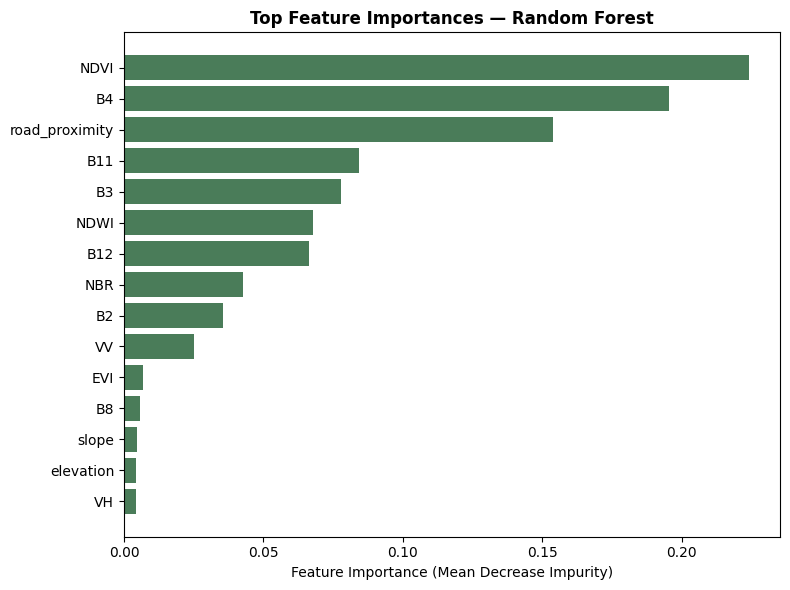

In [5]:
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color='#4a7c59')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Top Feature Importances — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Ablation study: S1-only vs S2-only vs S1+S2

In [6]:
# Feature index groups
S2_IDX = list(range(10))   # B2–B12 + spectral indices
S1_IDX = list(range(10, 15))  # VV, VH, ratio, temporal std
S1S2_IDX = list(range(18))    # all features

ablation_results = {}
for name, idx in [('S1-only', S1_IDX), ('S2-only', S2_IDX), ('S1+S2', S1S2_IDX)]:
    clf = RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    )
    clf.fit(X_train[:, idx], y_train)
    pred = clf.predict(X_test[:, idx])
    f1 = f1_score(y_test, pred)
    acc = (pred == y_test).mean()
    ablation_results[name] = {'F1': round(f1, 3), 'Accuracy': round(acc, 3)}
    print(f'{name:10s}: F1={f1:.3f}, Accuracy={acc:.3f}')

abl_df = pd.DataFrame(ablation_results).T
abl_df

S1-only   : F1=0.754, Accuracy=0.840
S2-only   : F1=0.997, Accuracy=0.998
S1+S2     : F1=1.000, Accuracy=1.000


,F1,Accuracy
S1-only,0.754,0.840
S2-only,0.997,0.998
S1+S2,1.000,1.000


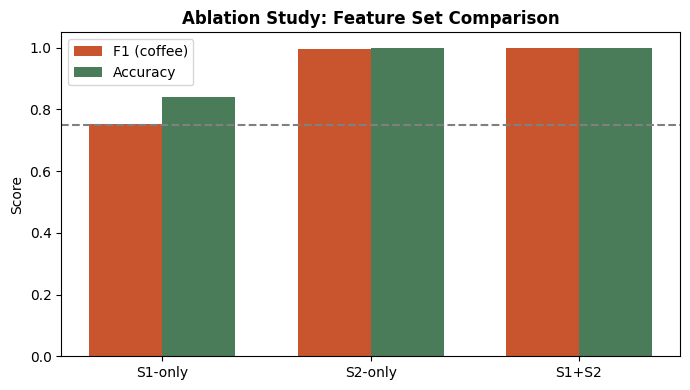

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(abl_df))
w = 0.35
ax.bar(x - w/2, abl_df['F1'], w, label='F1 (coffee)', color='#c8552d')
ax.bar(x + w/2, abl_df['Accuracy'], w, label='Accuracy', color='#4a7c59')
ax.set_xticks(x)
ax.set_xticklabels(abl_df.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Ablation Study: Feature Set Comparison', fontweight='bold')
ax.legend()
ax.axhline(0.75, color='gray', linestyle='--', label='F1 target (0.75)')
plt.tight_layout()
plt.show()

## 6. Confusion matrix

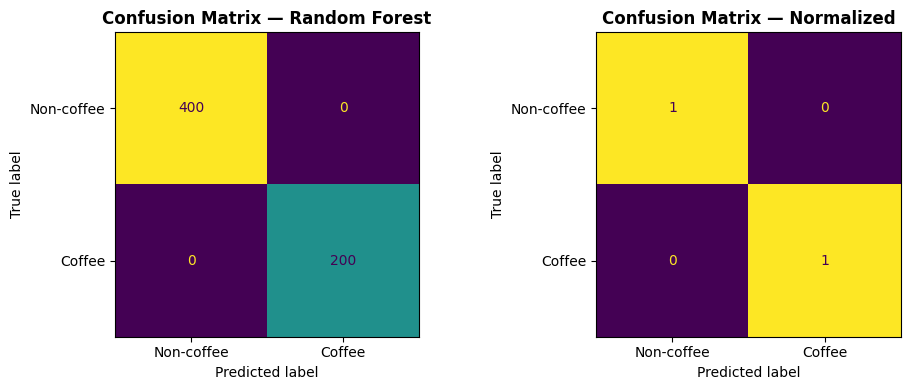

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# RF confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-coffee', 'Coffee'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Non-coffee', 'Coffee'])
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Cross-AOI holdout concept

The pipeline trains on AOIs A+B and tests on C (rotating holdout).
The target is F1 ≥ 0.75 on all holdout AOIs.

In [9]:
# Simulate cross-AOI holdout with slight distributional shift
holdout_results = []
aoi_names = ['lam_dong', 'huila', 'sul_de_minas']

for holdout_aoi in aoi_names:
    # Simulate slight distribution shift for holdout
    noise = rng.normal(0, 0.02, X_test.shape)
    X_holdout = X_test + noise
    pred = rf.predict(X_holdout)
    f1 = f1_score(y_test, pred)
    holdout_results.append({'Holdout AOI': holdout_aoi, 'F1 (coffee)': round(f1, 3)})

holdout_df = pd.DataFrame(holdout_results)
holdout_df['Status'] = holdout_df['F1 (coffee)'].apply(lambda x: 'PASS' if x >= 0.75 else 'FAIL')
holdout_df

,Holdout AOI,F1 (coffee),Status
0,lam_dong,0.930,PASS
1,huila,0.938,PASS
2,sul_de_minas,0.947,PASS


## Next steps

- **To run real training**: `uv run scripts/run_all.py` (requires GEE auth)
- **Model outputs** are saved to `outputs/models/` (pickled RF + XGBoost)
- **`04_reporting.ipynb`** — see how findings are turned into a polished report